In [ ]:
import h5py
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from ptychozoon.enhance import ElementMap, FluorescenceDataset, Product, VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm

import sys
sys.path.append("/home/beams1/B222816/scripts/readMDA.py")
from readMDA import *

## Load data

In [176]:

# get relevant xrf data
file_path = (
    "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/img.dat/bnp_fly0085.mda.h5"
)
with h5py.File(file_path, "r") as F:
    channel_names = [x.decode() for x in F["/MAPS/channel_names"][()]]
    element_maps = []
    for i, channel in enumerate(channel_names):
        element_maps += [
            ElementMap(channel, F["/MAPS/XRF_Analyzed/NNLS/Counts_Per_Sec"][i])
        ]
    xrf_pos_x = F["MAPS/x_axis"][()]
    xrf_pos_y = F["MAPS/y_axis"][()]
flourescence_in = FluorescenceDataset(element_maps)


# get ptycho data
file_path = "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/results/ML_recon/fly085/roi0_Ndp256/MLs_L1_p10_g1000_Ndp64_pc50_noModelCon_bg0.1_vp5_vi_mm/Niter1000.mat"
d = sio.loadmat(file_path)
pixel_size_m = d["p"]["dx_spec"][0][0][0][0]
ptycho_in = Product(
    # probe_positions=d["outputs"]["probe_positions"][0][0] * pixel_size_m,
    probe_positions=np.roll(d["outputs"]["probe_positions"][0][0] * pixel_size_m, 1),
    probe=d["probe"][:, :, :, 0].transpose(
        [2, 0, 1]
    ),  # removing opr for now, its also probably wrong
    object_array=d["object"],
    pixel_size_m=(pixel_size_m,) * 2,
    object_center_m = np.array([0, 0])
    # object_center_m=np.roll((np.array(d["object"].shape) / 2) * pixel_size_m, 0),
)



In [160]:
np.roll(ptycho_in.object_center_m, 0)

array([9.42062306e-06, 7.62724757e-06])

In [124]:
np.roll(ptycho_in.probe_positions, 1)

array([[ 6.45230791e-06, -4.93404333e-06],
       [-6.47833343e-06, -4.92998807e-06],
       [-6.47127728e-06, -4.82509441e-06],
       ...,
       [ 6.46661868e-06,  4.81817740e-06],
       [ 6.46778053e-06,  4.94858290e-06],
       [ 6.44047052e-06,  4.93545805e-06]], shape=(30777, 2))

In [174]:
ptycho_in.object_center_m

array([0, 0])

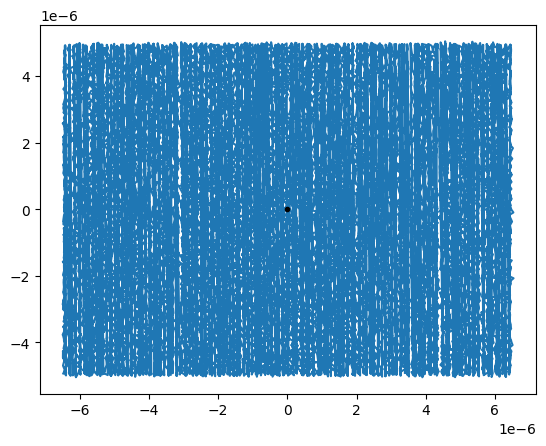

In [171]:
plt.plot(ptycho_in.probe_positions[:, 1], ptycho_in.probe_positions[:, 0])
plt.plot(0, 0, "k.")
plt.show()

## replicate original file

### Make file with indexing results

In [2]:
#!/APSshare/anaconda/x86_64/bin/python
import h5py
import numpy as np
import os #for change directory
import scipy.io as sio #for read/write matlab file
from numpy import *
import time
import scipy.ndimage
import glob
import pdb

import sys
import csv


sys.path.append("/home/beams1/B222816/scripts")
from readMDA import *
import datetime

# scans=np.arange(95,1000,1)
scans = [85]
#scans=[41]
# user_dir='/mnt/micdata1/bnp/2023-1/Isaure/'
user_dir = '/net/micdata/data1/bnp/2023-1/Isaure/'
data_dir =user_dir+'ptycho/'
result_dir = user_dir+'results/ML_recon/fly{:03d}/'
#xrf_file = user_dir+'img.dat/bnp_fly{:04d}.mda.h5'
xrf_file = user_dir+'img.dat/bnp_fly{:04d}.mda.h5'
mda_file=user_dir+'mda/bnp_fly{:04d}.mda'



energy = 12.3
det_sample_dist = 2.0578
det_pixel_size = 75e-6
cen_x = 503
cen_y = 268
det_Npixel = 128
lam = 1.23984193e-9/energy
dx = lam*det_sample_dist/det_pixel_size/det_Npixel #pixel size
filePath = '/entry/data/data'
print("real-space pixel size: " + str(dx))

N_scan_x_lb = 0
N_scan_y_lb = 1
roi='0_Ndp' + str(det_Npixel)

# while True:
for scanNo in scans:
    
    data_dir_next = mda_file.format(scanNo)
    dataExist = os.path.isfile(data_dir_next)
    if not dataExist:
        print('Scan No.' + str(scanNo+1) + '-Data does not exist!')
        continue

    dataName = 'data_roi' + roi + '_dp.hdf5'
    dataExists = os.path.isfile(result_dir.format(scanNo)+dataName)
    if dataExists:
        print('Scan No.' + str(scanNo) + '-Data already exists!')
        continue    
    #pdb.set_trace()
    if not os.path.exists(result_dir.format(scanNo)): os.makedirs(result_dir.format(scanNo))
    print(result_dir.format(scanNo))

    #############Getting scan position############
    #XRFfile=h5py.File(xrf_file.format(scanNo))
    #x_pos=XRFfile['MAPS/x_axis'].value
    #y_pos=XRFfile['MAPS/y_axis'].value
    mda_data=readMDA(mda_file.format(scanNo))
    y_pos=np.array(mda_data[1].p[0].data) # HR uncomment
    y_pos=y_pos[np.argwhere(y_pos!=0.0)]  #incomplete scan shows 0 for unscanned lines
    x_pos=np.array(mda_data[2].p[0].data)[0]
    #pdb.set_trace()
    x_pos-=x_pos.mean()
    y_pos-=y_pos.mean()
    x_pos*=1e-6
    y_pos*=1e-6

    N_scan_x = x_pos.shape[0]
    print('X scan points: {:d}'.format(N_scan_x))
    N_scan_y = y_pos.shape[0]
    print('y scan points: {:d}'.format(N_scan_y))

    #############Loading diffraction patterns and poistions############
    scan_posx=0
    scan_posy=0 
    diffs=[]
    for i in range(N_scan_y-N_scan_y_lb):
        print("Iteration:", i)
        #fileName = data_dir+'fly{:03d}_data_{:06d}.h5'.format(scanNo,i+1+N_scan_y_lb)
        fileName = data_dir+'bnp_fly{:04d}_{:06d}.h5'.format(scanNo,i+N_scan_y_lb)        
        try:
            #pdb.set_trace()
            h5_data = h5py.File(fileName,'r')
            # dp_temp = h5_data[filePath].value # HR uncomment
            dp_temp = h5_data[filePath][()]
            dp_temp[dp_temp<0] = 0
            dp_temp[dp_temp>1e7] = 0
            print(fileName, dp_temp.shape)
            ith_line_N=dp_temp.shape[0]
            if ith_line_N<5:
                print('A lot of pixels are missed on this line:{:d}pxiels, Skip!'.fomrat(ith_line_N))
                continue
            if len(diffs)==0:
                # diffs=dp_temp[:,cen_y-det_Npixel/2:cen_y+det_Npixel/2,cen_x-det_Npixel/2:cen_x+det_Npixel/2] # HR uncomment
                diffs = dp_temp[:,cen_y-det_Npixel//2:cen_y+det_Npixel//2,cen_x-det_Npixel//2:cen_x+det_Npixel//2] # HR add
                scan_posx=x_pos[:ith_line_N]
                scan_posy=np.ones(ith_line_N)*y_pos[i+N_scan_y_lb]
            else:
                # diffs=np.append(diffs,dp_temp[:,cen_y-det_Npixel/2:cen_y+det_Npixel/2,cen_x-det_Npixel/2:cen_x+det_Npixel/2],axis=0)
                diffs=np.append(diffs,dp_temp[:,cen_y-det_Npixel//2:cen_y+det_Npixel//2,cen_x-det_Npixel//2:cen_x+det_Npixel//2],axis=0)
                scan_posx=np.append(scan_posx,x_pos[:ith_line_N])
                scan_posy=np.append(scan_posy,np.ones(ith_line_N)*y_pos[i+N_scan_y_lb])
            h5_data.close()
        except:
            print("Has problem with opening file: {:s}".format(fileName))
            break
            # pass

    dp_sum=np.sum(diffs,axis=(1,2))
    #pdb.set_trace()
    pos_index=np.argwhere(dp_sum>(dp_sum.mean()/1.08))
    diffs=diffs[pos_index[:,0]]
    scan_posx=scan_posx[pos_index[:,0]]
    scan_posy=scan_posy[pos_index[:,0]]
    #print scan_posx.shape[0]
    #print scan_posy.shape[0]
    print(len(diffs))
    ##################### save data ##########################
    # print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir.format(scanNo))
    # f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_dp.hdf5', "w")
    # f.create_dataset("dp", dtype='float64', data=diffs, compression="gzip")
    # #f.create_dataset("dp", data=diffs, compression="gzip")
    # f.close()
    # #save other parameters
    # f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_para.hdf5', "w")
    # f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
    # f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
    # f.create_dataset("ppY", dtype='float64', data=scan_posy)
    # f.create_dataset("ppX", dtype='float64', data=scan_posx)

    # f.create_dataset("N_scan_y_lb", shape=(1,),dtype='int', data=N_scan_y_lb)
    # f.create_dataset("N_scan_x_lb", shape=(1,),dtype='int', data=N_scan_x_lb)
    # f.create_dataset("N_scan_y", shape=(1,),dtype='int', data=N_scan_y)
    # f.create_dataset("N_scan_x", shape=(1,),dtype='int', data=N_scan_x)
    # f.close()
# time.sleep(5)


real-space pixel size: 2.1606933634434283e-08
/net/micdata/data1/bnp/2023-1/Isaure/results/ML_recon/fly085/
/net/micdata/data1/bnp/2023-1/Isaure/mda/bnp_fly0085.mda is a 2-D file; 2 dimensions read in.
dim[0] = dictionary of 42 scan-environment PVs
   usage: dim[0]['sampleEntry'] -> ('description', 'unit string', 'value')
dim[1] = 1D data from "9idbBNP:scan2": 201/201 pts; 4 pos's, 6 dets, 3 trigs
dim[2] = 2D data from "9idbBNP:scan1": 154/154 pts; 1 pos's, 42 dets, 2 trigs
   usage: dim[1].p[2].data -> 1D array of positioner 2 data
   usage: dim[2].d[7].data -> 2D array of detector 7 data
X scan points: 154
y scan points: 201
Iteration: 0
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000001.h5 (154, 1062, 1028)
Iteration: 1
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000002.h5 (154, 1062, 1028)
Iteration: 2
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000003.h5 (154, 1062, 1028)
Iteration: 3
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_00000

In [5]:
result_dir = "/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/"

print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir.format(scanNo))
f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_dp.hdf5', "w")
f.create_dataset("dp", dtype='float64', data=diffs, compression="gzip")
#f.create_dataset("dp", data=diffs, compression="gzip")
f.close()

saving data_roi0_Ndp128.hdf5 to /local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/


In [23]:
#save other parameters
print("save other params")
f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_para.hdf5', "w")
f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
f.create_dataset("ppY", dtype='float64', data=scan_posy)
f.create_dataset("ppX", dtype='float64', data=scan_posx)

f.create_dataset("N_scan_y_lb", shape=(1,),dtype='int', data=N_scan_y_lb)
f.create_dataset("N_scan_x_lb", shape=(1,),dtype='int', data=N_scan_x_lb)
f.create_dataset("N_scan_y", shape=(1,),dtype='int', data=N_scan_y)
f.create_dataset("N_scan_x", shape=(1,),dtype='int', data=N_scan_x)

f.create_dataset("pos_index", dtype='int', data=[x[0] for x in pos_index])

f.close()

save other params


### Get invalid indices

In [ ]:
# load 
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]
xrf_shape = flourescence_in.element_maps[2].counts_per_second.shape
n_points = np.prod(xrf_shape)
invalid_position_index = [x for x in range(0, n_points) if x not in valid_position_index]
# invalid_coords = np.unravel_index(
#     invalid_position_index, xrf_shape
# )


#### <misc>

In [78]:
invalid_coords
invalid_position_index

[1452,
 2977,
 3494,
 4996,
 5513,
 7015,
 8022,
 9057,
 10039,
 11073,
 13578,
 14612,
 17116,
 17633,
 18101,
 19106,
 23155,
 25175,
 25692,
 26182,
 26676,
 28201,
 28718,
 30800,
 30801,
 30802,
 30803,
 30804,
 30805,
 30806,
 30807,
 30808,
 30809,
 30810,
 30811,
 30812,
 30813,
 30814,
 30815,
 30816,
 30817,
 30818,
 30819,
 30820,
 30821,
 30822,
 30823,
 30824,
 30825,
 30826,
 30827,
 30828,
 30829,
 30830,
 30831,
 30832,
 30833,
 30834,
 30835,
 30836,
 30837,
 30838,
 30839,
 30840,
 30841,
 30842,
 30843,
 30844,
 30845,
 30846,
 30847,
 30848,
 30849,
 30850,
 30851,
 30852,
 30853,
 30854,
 30855,
 30856,
 30857,
 30858,
 30859,
 30860,
 30861,
 30862,
 30863,
 30864,
 30865,
 30866,
 30867,
 30868,
 30869,
 30870,
 30871,
 30872,
 30873,
 30874,
 30875,
 30876,
 30877,
 30878,
 30879,
 30880,
 30881,
 30882,
 30883,
 30884,
 30885,
 30886,
 30887,
 30888,
 30889,
 30890,
 30891,
 30892,
 30893,
 30894,
 30895,
 30896,
 30897,
 30898,
 30899,
 30900,
 30901,
 30902,


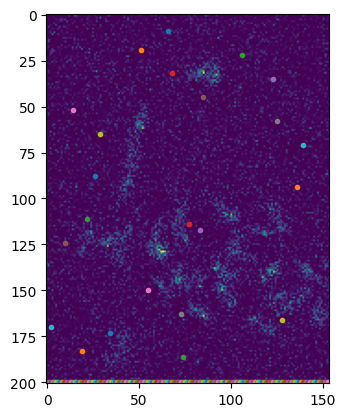

In [62]:
a = flourescence_in.element_maps[2].counts_per_second
plt.imshow(a)
n = len(invalid_coords[0])
for i in range(n):
    plt.plot(invalid_coords[1][i], invalid_coords[0][i], '.')
plt.show()

In [71]:
i=30
flourescence_in.element_maps[2].counts_per_second[invalid_coords[0][i], invalid_coords[1][i]]

np.float32(0.0)

In [74]:
np.where(flourescence_in.element_maps[2].counts_per_second==0)[0]

array([  0,   0,   0, ..., 200, 200, 200], shape=(7610,))

In [ ]:
# load 
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]

In [36]:
np.unravel_index(
    valid_position_index, flourescence_in.element_maps[2].counts_per_second.shape
)


(array([  0,   0,   0, ..., 199, 199, 199], shape=(30777,)),
 array([  0,   1,   2, ..., 151, 152, 153], shape=(30777,)))

In [63]:
ptycho_in.probe_positions.shape

(30777, 2)

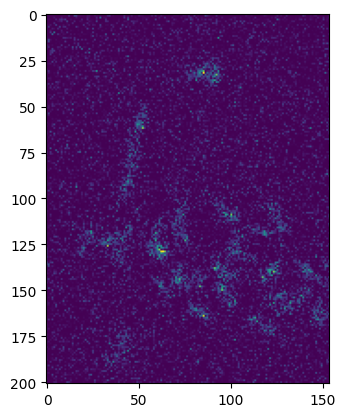

In [42]:
plt.imshow(flourescence_in.element_maps[2].counts_per_second)
plt.show()

In [45]:
np.prod(flourescence_in.element_maps[2].counts_per_second.shape)

np.int64(30954)

In [37]:
flourescence_in.element_maps[2].counts_per_second[valid_position_index]

IndexError: index 201 is out of bounds for axis 0 with size 201

## test vspi

In [181]:
import importlib
import ptychozoon
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)

<module 'ptychozoon.enhance' from '/home/beams0/HRUTH/code/ptycho_development/ptychozoon/src/ptychozoon/enhance.py'>

In [ ]:
flourescence_result = VSPIFluorescenceEnhancingAlgorithm(max_iterations=5).enhance(
    flourescence_in, ptycho_in, valid_position_index, select_maps="K"
)


 
LSMR            Least-squares solution of  Ax = b

The matrix A has 30777 rows and 153908 columns
damp = 0.00000000000000e+00

atol = 1.00e-06                 conlim = 1.00e+08

btol = 1.00e-06             maxiter =        5

 
   itn      x(1)       norm r    norm Ar  compatible   LS      norm A   cond A
     0  0.00000e+00  3.645e+02  2.136e+02   1.0e+00  1.6e-03


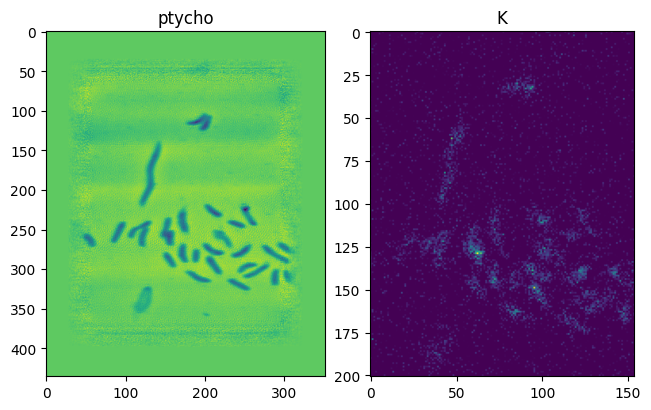

In [2]:
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second)
plt.show()

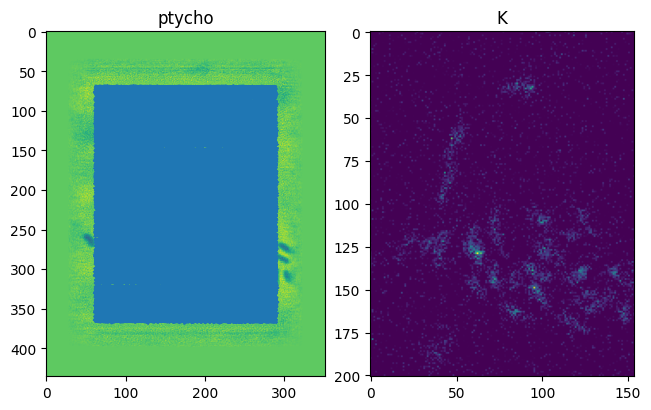

In [152]:
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.plot(
    ptycho_in.probe_positions[:, 0] / ptycho_in.pixel_size_m[0]
    + ptycho_in.object_center_m[0] / ptycho_in.pixel_size_m[0],
    ptycho_in.probe_positions[:, 1] / ptycho_in.pixel_size_m[0]
    + ptycho_in.object_center_m[1] / ptycho_in.pixel_size_m[0],
)
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second)
plt.show()

In [ ]:
ptycho_in.object_center_m[1] / ptycho_in.pixel_size_m[0]


np.float64(176.5)

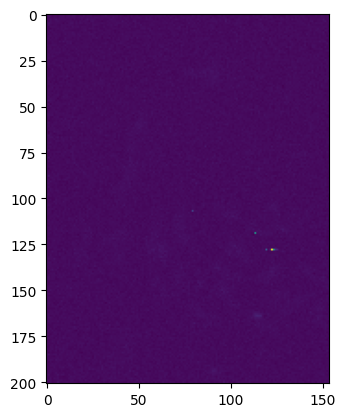

In [ ]:
plt.imshow(flourescence_in.element_maps[0].counts_per_second.sum(0))
plt.show()

In [ ]:
Product(
    probe_positions=d["outputs"]["probe_positions"][0][0],
    probe=d["probe"][:, :, :, 0].transpose([2, 0, 1]), # removing opr for now, its also probably wrong
    object_array=d["object"],
    pixel_size_m=d["p"]["dx_spec"][0][0][0][0],
    object_center_m=(np.array(d["object"].shape)/2).astype(int),
)



Product(probe_positions=array([[-114.17731476, -149.91329956],
       [-114.08347321, -149.75001526],
       [-111.65615845, -149.14329529],
       ...,
       [ 111.49609375,  149.6690979 ],
       [ 114.51377106,  149.03712463],
       [ 114.21005249,  149.31105042]], shape=(30777, 2)), probe=array([[[-6.94444627e-02-1.13792956e-01j,
          5.07903993e-02-1.90125391e-01j,
          9.34065059e-02-9.26876217e-02j, ...,
         -6.85116053e-02-8.20307955e-02j,
         -1.07632451e-01-5.86915389e-02j,
         -1.60584867e-01-2.22238209e-02j],
        [ 3.80921289e-02-9.73001570e-02j,
          1.32195398e-01-4.41820547e-02j,
          9.27065164e-02+2.08250377e-02j, ...,
         -1.14096375e-02-4.28931154e-02j,
         -1.24256395e-01-2.40184292e-02j,
         -1.13238305e-01-4.91660573e-02j],
        [ 2.21461076e-02-7.65721798e-02j,
          4.95413318e-02+3.07254102e-02j,
          3.37143913e-02+2.31780931e-02j, ...,
          7.26277241e-03-7.53203258e-02j,
         -7.480

In [ ]:
(np.array(d["object"].shape)/2).astype(int)

array([218. , 176.5])

In [ ]:
d["p"]["dx_spec"][0][0][0][0]

np.float64(4.3213867268868566e-08)

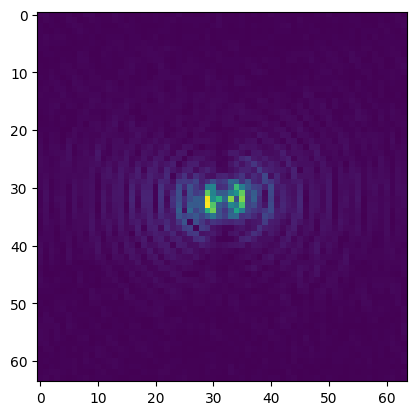

In [ ]:
d["outputs"]["probe_positions"][0][0]
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(np.abs(d["probe"][:, :, 1, 0]))
plt.show()